# Estimate the effects of amino acid substitutions on fitness
$$
\frac{1}{n}\left( \Delta s - W a \right)^\top C^{-1} \left( \Delta s - W a \right) + \lambda \lVert a \rVert_1
$$

$a$ describes the impact on fitness of specific amino acid substitutions. $W$ is the assignment of amino acid substitutions of pango lineages compared to their parent lineage, $C$ the diagonal covariance matrix between growth rate differences and $\Delta s$ the difference in growth rate between a pango lineage and its parent.

In [ ]:
import pandas as pd
import numpy as np

import cvxpy as cp
from scipy.linalg import cholesky

from matplotlib import pyplot as plt
import seaborn as sns

from viral_variant_comp.aa_subst_impact import create_substitutions_df, create_pango_lineage_information_df, calculate_fitness_advantage_covariance, calculate_impact_estimates, bootstrap_aa_impact_estimates, calculate_impact_estimates_timesplit, get_most_impactful_substitutions
from viral_variant_comp.plotting import plot_bootstrap_aa_impact, plot_bootstrap_aa_impact_violin, plot_loss_different_lambda, plot_aa_impac_distr_lambdas, plot_aa_impact_dist_cov, plot_aa_impact_time

/opt/homebrew/Caskroom/miniforge/base/envs/neherlab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Estimate Impact of Amino Acid Substitutions on fitness
$\Delta s$ describes the difference in fitness between each child and its parent linegae. 
This difference in fitness can be modeled as the sum of the impacts of the amino acid substitutions that led to the formation of the child lineage:
\begin{equation}
    \Delta s \approx W \cdot a
\end{equation}
$W$ is the binary assignment matrix, which assigns all substitutions between a child and parent lineage to each child lineage.
Using this we can solve a quadratic optimization problem to estimate the amino acid impact vector $a$:
\begin{equation}
    \mathcal{L}(a) =\left( \Delta s - W a \right)^\top C^{-1} \left( \Delta s - W a \right) + \lambda \lVert a \rVert_1
\end{equation}
This loss function includes an $l1$-regularization term with regularization parameter $\lambda$, based on the assumption that many amino acid substitutions have no impact on fitness. $C$ is the covariance matrix of $\Delta s$. The optimization problem is solved using the OSQP solver, implemented in the \texttt{cvxpy} package. 

## Prepare Data 
We again use the SARS-CoV-2 data set between January 2020 and April 2025 in the US.

In [ ]:
# load data frame with amino acid substitutions to its parent for each lineage, information about the parent lineage
url_pango_consensus_seq = "https://raw.githubusercontent.com/corneliusroemer/pango-sequences/refs/heads/main/data/pango-consensus-sequences_summary.json"
consensus_seq_df = pd.read_json(url_pango_consensus_seq)
consensus_seq_df.head()

,A,A.1,A.2,A.2.2,A.2.3,A.2.4,A.2.5,A.2.5.1,A.2.5.2,A.2.5.3,...,XP,XQ,XR,XS,XT,XU,XV,XW,XY,XZ
lineage,A,A.1,A.2,A.2.2,A.2.3,A.2.4,A.2.5,A.2.5.1,A.2.5.2,A.2.5.3,...,XP,XQ,XR,XS,XT,XU,XV,XW,XY,XZ
unaliased,A,A.1,A.2,A.2.2,A.2.3,A.2.4,A.2.5,A.2.5.1,A.2.5.2,A.2.5.3,...,XP,XQ,XR,XS,XT,XU,XV,XW,XY,XZ
parent,,A,A,A.2,A.2,A.2,A.2,A.2.5,A.2.5,A.2.5,...,,,,,,,,,,
children,"[A.1, A.2, A.3, A.4, A.5, A.6, A.7, A.9, A.11,...",[],"[A.2.2, A.2.3, A.2.4, A.2.5]",[],[],[],"[A.2.5.1, A.2.5.2, A.2.5.3]",[],[],[],...,[],[],[],[],[],[],[],[],[],[]
nextstrainClade,19B,19B,19B,19B,19B,19B,19B,19B,19B,19B,...,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant,recombinant


In [ ]:
# create dataframe assigning new amino acid substitutions compared to its parent lineage to each lineage
substitutions_df = create_substitutions_df(consensus_seq_df)
substitutions_df


,E:A41V,E:D72G,E:E8D,E:F20L,E:F23V,E:F26L,E:L18I,E:L21F,E:L51I,E:L73F,...,S:Y248S,S:Y265C,S:Y266H,S:Y269N,S:Y28H,S:Y449H,S:Y449N,S:Y451H,S:Y453F,S:Y505H
A,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A.2.2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
A.2.3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XU,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
XV,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
XW,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
XY,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# combine results of variant fitness estimation with child parent lineage assignment to create a dataframe summariizing data for each lineage including fitness advantage towards its parent lineage
pango_clade_mapping = pd.read_csv('data/covid_results/pango_clade_mapping_window300_pivotA5.csv')

lineage_info_df = create_pango_lineage_information_df(pango_clade_mapping, consensus_seq_df)
lineage_info_df

,lineage,clade,pango_growth,clade_growth,pango_lif,clade_lif,pango_time,clade_time,parent,parent_growth_advantage
0,A.5,19B,0.000000,0.000000,0.000000,0.000000,45.181818,150.199306,A,-0.104699
1,A.1,19B,0.061626,0.000000,2.655418,0.000000,59.252306,150.199306,A,-0.043073
2,A.3,19B,0.069903,0.000000,1.155658,0.000000,63.350183,150.199306,A,-0.034796
3,A.2,19B,0.096689,0.000000,-3.888758,0.000000,107.638889,150.199306,A,-0.008009
5,A.19,19B,0.113630,0.000000,-10.290943,0.000000,246.000000,150.199306,A,0.008932
...,...,...,...,...,...,...,...,...,...,...
2985,NY.1,25A,1.085404,0.711105,-990.380803,-660.436942,1843.843750,1837.413845,LP.8.1.1,-0.002543
2986,NY.3,25A,1.085721,0.711105,-989.395070,-660.436942,1844.103896,1837.413845,LP.8.1.1,-0.002225
2987,LP.8.1.1,25A,1.087947,0.711105,-990.545404,-660.436942,1845.879013,1837.413845,LP.8.1,0.018683
2988,NW.1,25A,1.098315,0.711105,-1013.497309,-660.436942,1853.132353,1837.413845,LP.8.1.2,0.035350


- Only variants that have been sequenced at least once (in the US) are considered in the growth rate estimation, this looses 197 from the pango-clade-mapping dataframe
- only pango lineages are kept that are part of the pango clade mapping dataframe, this looses 118 lineages
- also consensus_seq_df contains more variants than included in the growth rate estimation (1378) and 3 can't be looked up.

For now, I'll include only pango lineages, that are present in all three dataframes and whoose parents have a growth rate estimate


#### Calculate covariance matrix
To calculate the covariance matric of $\Delta s$, we can use the covariance matrix calculated for $s$ before and transform it
$$
d_i = s_c^{(i)} - s_p^{(i)} = (D \cdot s)_i
$$

$$
Cov(d) = Cov (D \cdot s) = D \cdot Cov(s) \cdot D^T
$$

In [10]:
hess_inv = np.loadtxt('data/covid_results/inv_hessian_window300_pivotA5.txt', delimiter=',')
lineage_names = np.loadtxt('data/covid_results/variant_names_pivotA5.txt', delimiter=',', dtype=str)

C = calculate_fitness_advantage_covariance(hess_inv, lineage_names, lineage_info_df)
np.diag(C)

array([3.95202938e-04, 1.11252770e-06, 1.64279945e-06, ...,
       8.71148404e-07, 3.03069139e-05, 7.01380544e-05], shape=(2940,))

## Estimate Amino Acid Substitution Impact

In [ ]:
# load all data and calculate impact estimates (calculate_impact_estimates summarizes all previous calculations)

pango_clade_mapping = pd.read_csv('data/covid_results/pango_clade_mapping_window300_pivotA5.csv')
hess_inv = np.loadtxt('data/covid_results/inv_hessian_window300_pivotA5.txt', delimiter=',')
lineage_names = np.loadtxt('data/covid_results/variant_names_pivotA5.txt', delimiter=',', dtype=str)
url_pango_consensus_seq = "https://raw.githubusercontent.com/corneliusroemer/pango-sequences/refs/heads/main/data/pango-consensus-sequences_summary.json"
consensus_seq_df = pd.read_json(url_pango_consensus_seq)

aa_impact = calculate_impact_estimates(consensus_seq_df, hess_inv, lineage_names, pango_clade_mapping, _lambda=0.05, calc_max_lambda_loss=True)
aa_impact_diag_C = calculate_impact_estimates(consensus_seq_df, hess_inv, lineage_names, pango_clade_mapping, _lambda=0.05, diag_covariance=True)

(2940, 4288)
Status: optimal
Optimal value of objective function: 19.846670133381608
Max lambda loss: 639.3564543704088
(2940, 4288)
Status: optimal
Optimal value of objective function: 19.864466500413773


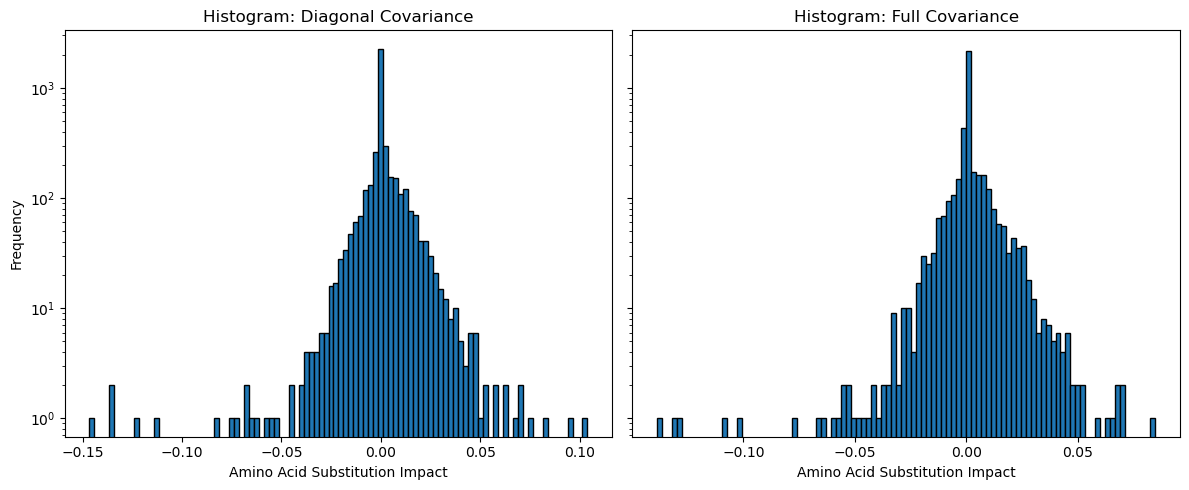

In [ ]:
# compate using a covariance matrix with diagonal elements only to the full covariance matrix
plot_aa_impact_dist_cov(aa_impact['a_est'], aa_impact_diag_C['a_est'])

### Choose suitable lambda parameter

In [13]:
# List of lambda values to test
lambda_values = [0.00001, 0.00005, 0.0001, 0.0005, 0.001, 0.005, 0.01,0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]

# Dictionary to store impacts for each lambda
aa_impact_C_dict = {}

# Run estimate_aa_impact for each lambda
for lam in lambda_values:
    aa_impact_C = calculate_impact_estimates(consensus_seq_df, hess_inv, lineage_names, pango_clade_mapping, _lambda=lam)
    aa_impact_C_dict[lam] = aa_impact_C

(2940, 4288)
Status: optimal
Optimal value of objective function: 18.634654934552767
(2940, 4288)
Status: optimal
Optimal value of objective function: 18.63577060428062
(2940, 4288)
Status: optimal
Optimal value of objective function: 18.63717755639262
(2940, 4288)
Status: optimal
Optimal value of objective function: 18.648447198084835
(2940, 4288)
Status: optimal
Optimal value of objective function: 18.66242877909472
(2940, 4288)
Status: optimal
Optimal value of objective function: 18.772225320017586
(2940, 4288)
Status: optimal
Optimal value of objective function: 18.904115240512052
(2940, 4288)
Status: optimal
Optimal value of objective function: 19.846670133381608
(2940, 4288)
Status: optimal
Optimal value of objective function: 20.849722794355856
(2940, 4288)
Status: optimal
Optimal value of objective function: 26.543226144020345
(2940, 4288)
Status: optimal
Optimal value of objective function: 31.46025412662727
(2940, 4288)
Status: optimal
Optimal value of objective function: 54.

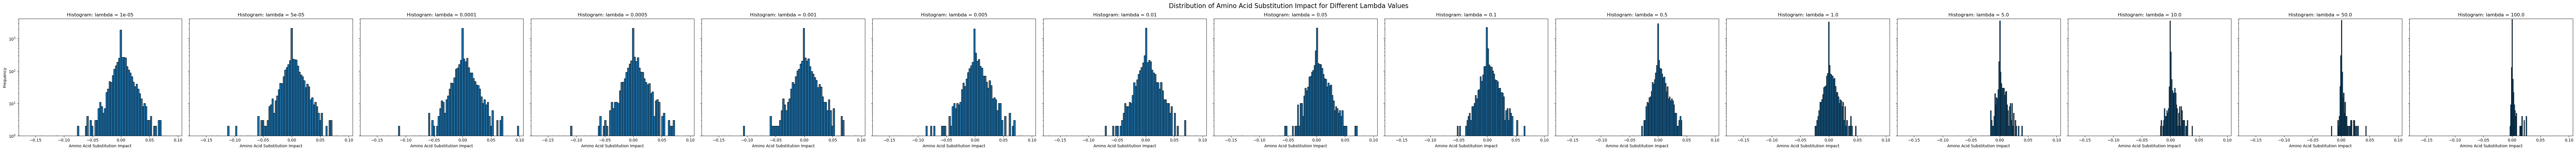

In [14]:
plot_aa_impac_distr_lambdas(lambda_values, aa_impact_C_dict)


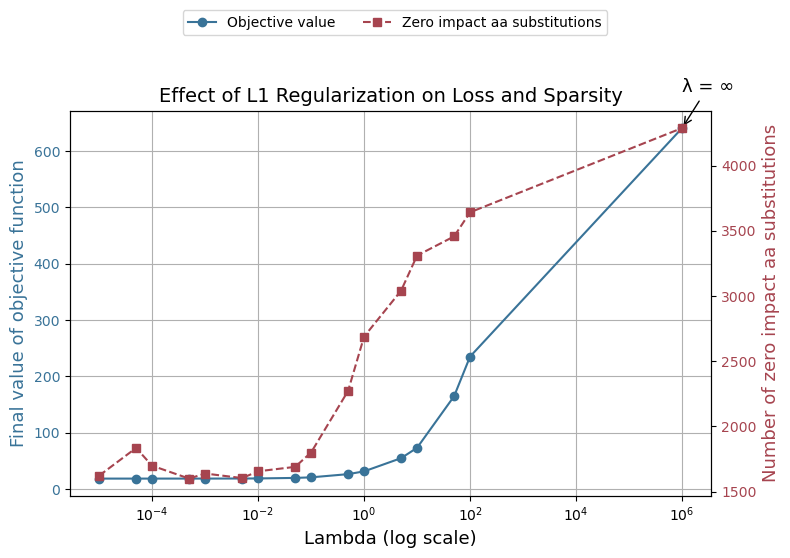

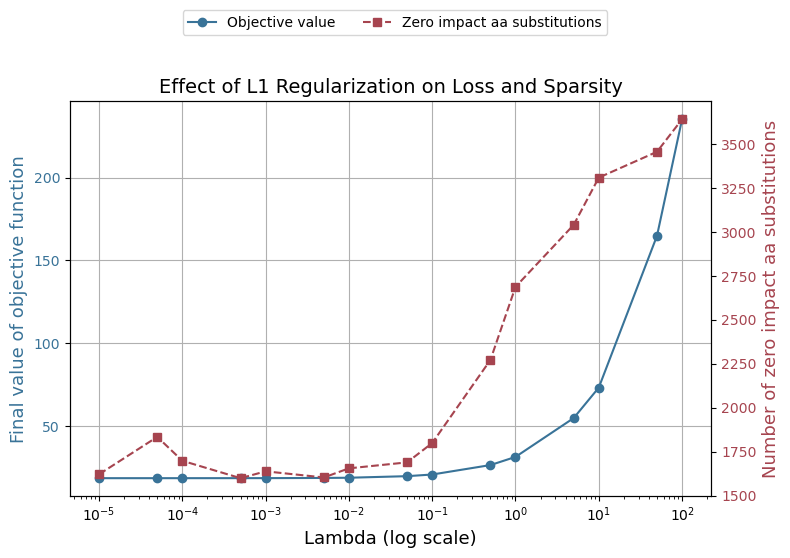

In [84]:
objective_vals = [imp['objective_value'] for imp in aa_impact_C_dict.values()]
n_zero_aa_impact = [(np.abs(imp['a_est']) < 0.0001).sum() for imp in aa_impact_C_dict.values()]
n_aa_subst = aa_impact_C_dict[1]['a_est'].shape[0]

plot_loss_different_lambda(objective_vals, n_zero_aa_impact, lambda_values, n_aa_subst, add_inf_lambda=True)
plot_loss_different_lambda(objective_vals, n_zero_aa_impact, lambda_values, n_aa_subst, add_inf_lambda=False)

In [17]:
aa_impact_df_1 = get_most_impactful_substitutions(aa_impact_C_dict[1.0]['a_est'], 20, substitutions_df, lineage_info_df)
aa_impact_df_1

,aa_substitution,gr_impact,n_events
S:F486P,S:F486P,0.046979,32
S:N460K,S:N460K,0.036700,23
S:N450D,S:N450D,0.029701,24
S:A435S,S:A435S,0.029219,14
S:F456L,S:F456L,0.027649,77
ORF9b:I5T,ORF9b:I5T,0.027457,11
S:R346T,S:R346T,0.026412,117
S:L455F,S:L455F,0.025154,29
S:V445P,S:V445P,0.024603,20
S:R403K,S:R403K,0.024293,12


In [18]:
aa_impact_df_1 = get_most_impactful_substitutions(aa_impact_C_dict[0.01]['a_est'], 20, substitutions_df, lineage_info_df)
aa_impact_df_1

,aa_substitution,gr_impact,n_events
S:F486P,S:F486P,0.052940,32
S:A435S,S:A435S,0.037492,14
S:N460K,S:N460K,0.037302,23
ORF9b:I5T,ORF9b:I5T,0.034324,11
S:T22N,S:T22N,0.029874,23
S:G446S,S:G446S,0.029849,12
S:F456L,S:F456L,0.029759,77
S:N450D,S:N450D,0.029099,24
S:R346T,S:R346T,0.026575,117
S:L455F,S:L455F,0.025572,29


## Evaluate accuracy of results
Use bootstrapping to see how often an amino acid is chosen in the top 20 amino acids. Chosse $ \lambda = 0.1$

In [39]:
pango_clade_mapping = pd.read_csv('data/covid_results/pango_clade_mapping_window300_pivotA5.csv')
hess_inv = np.loadtxt('data/covid_results/inv_hessian_window300_pivotA5.txt', delimiter=',')
lineage_names = np.loadtxt('data/covid_results/variant_names_pivotA5.txt', delimiter=',', dtype=str)
url_pango_consensus_seq = "https://raw.githubusercontent.com/corneliusroemer/pango-sequences/refs/heads/main/data/pango-consensus-sequences_summary.json"
consensus_seq_df = pd.read_json(url_pango_consensus_seq)

bootstrap_results_df, bootstrap_array = bootstrap_aa_impact_estimates(consensus_seq_df, hess_inv, lineage_names, pango_clade_mapping, _lambda=0.1, n_runs=30, diag_covariance=False)

Min eigenvalue: (-1.9988401380223083e-19+0j)
Status: optimal
Optimal value of objective function: 10.701273416677033
Bootstrap run 1:
10.701273416677033
Min eigenvalue: (-1.725559924261407e-19+0j)
Status: optimal
Optimal value of objective function: 14.995249227928616
Bootstrap run 2:
14.995249227928616
Min eigenvalue: (-1.383168316373275e-19+0j)
Status: optimal
Optimal value of objective function: 10.29979405710534
Bootstrap run 3:
10.29979405710534
Min eigenvalue: (-1.1359509329421535e-19-1.3130482776853677e-20j)
Status: optimal
Optimal value of objective function: 12.014687759601257
Bootstrap run 4:
12.014687759601257
Min eigenvalue: (-2.182777372901091e-19+0j)
Status: optimal
Optimal value of objective function: 12.87040098491791
Bootstrap run 5:
12.87040098491791
Min eigenvalue: (-1.7399535983952395e-19+0j)
Status: optimal
Optimal value of objective function: 12.608000820456887
Bootstrap run 6:
12.608000820456887
Min eigenvalue: (-1.8633683395289305e-19+0j)
Status: optimal
Optimal

In [40]:
bootstrap_results_df[bootstrap_results_df.n_events > 10].head(20)


,mean,std,ci_lower,ci_upper,aa_substitution,n_events
0,0.055460,0.007548,0.042927,0.067933,S:F486P,32
9,0.037380,0.007150,0.021079,0.046376,S:A435S,14
10,0.036639,0.005702,0.029540,0.047882,S:N460K,23
14,0.031268,0.004501,0.026246,0.044483,S:F456L,77
16,0.030817,0.004487,0.023157,0.039880,S:N450D,24
23,0.027375,0.006270,0.017462,0.038876,S:T22N,23
25,0.026374,0.003080,0.021634,0.032295,S:R346T,117
26,0.026317,0.007776,0.018133,0.041449,S:V445P,20
27,0.025748,0.011643,0.018132,0.051308,S:L452R,27
29,0.025726,0.002032,0.022258,0.030063,S:L455F,29


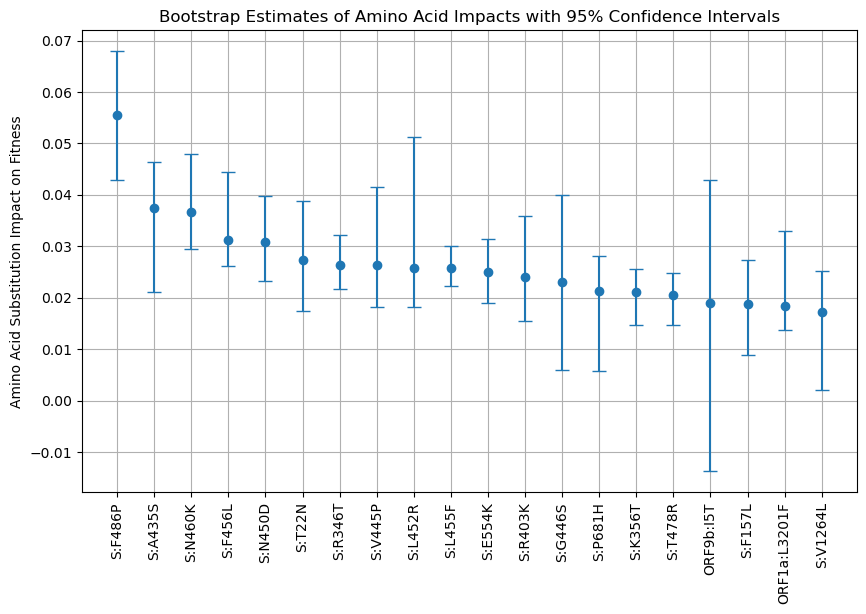

In [41]:
plot_bootstrap_aa_impact(bootstrap_results_df, 20, abundancy_threshold=10)

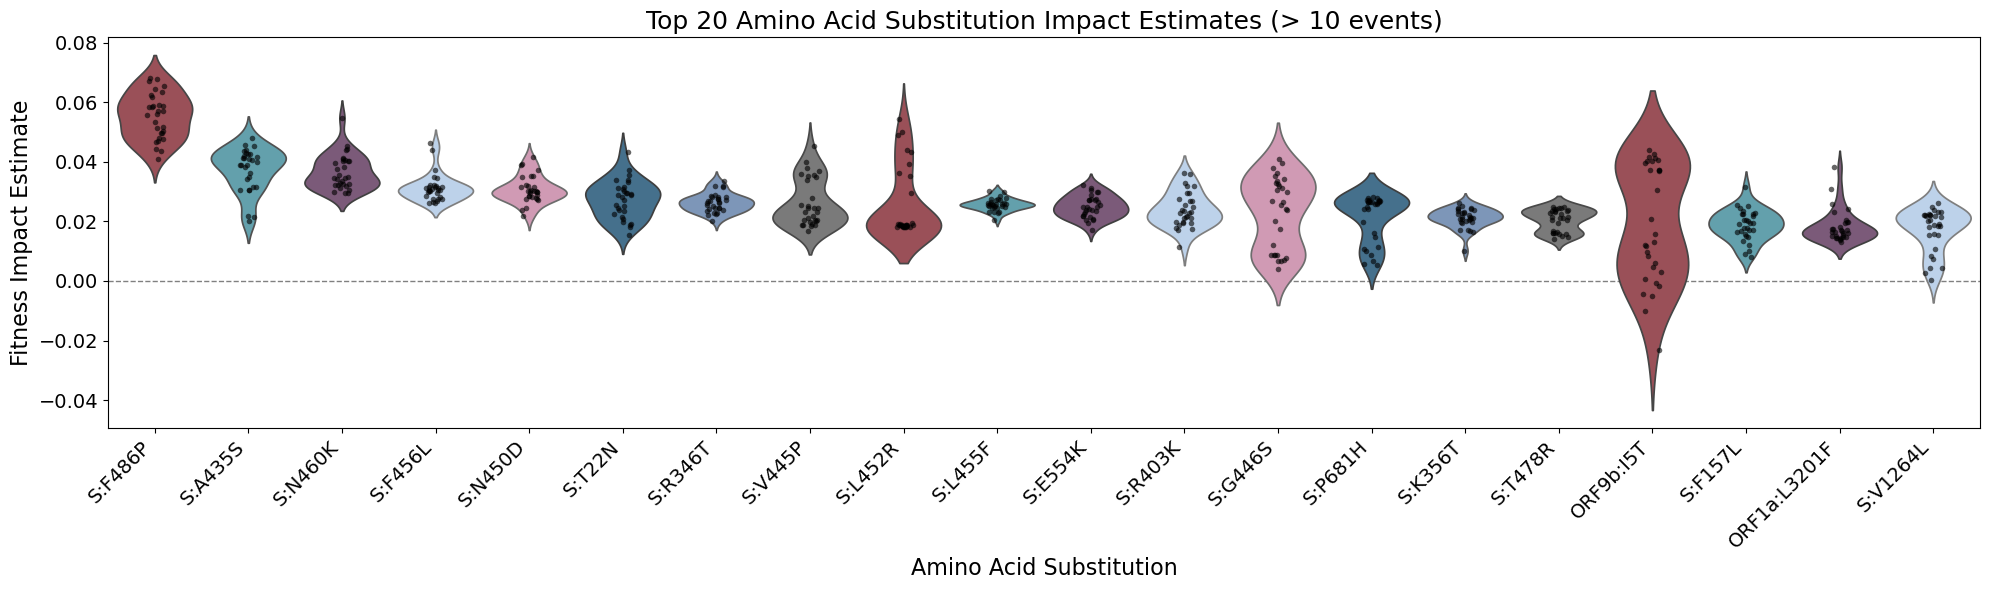

In [93]:
plot_bootstrap_aa_impact_violin(bootstrap_results_df, bootstrap_array, 20, abundancy_threshold=10)

### Consider amino acid substitutions impact over time

As a next step, we want to see if the impact of amino acid substitutions changes over time. To do this, we split the known amino acid clades into 4 time intervals:
- alpha to delta variants: A.1 to AY..., clades: 19B to 21J, around January 2020 to December 2021
- omicron: BA.1 ..., clades: 21K to 23C, aroung January 2022 to December 2022
- omicron XBB: XBB.1 ... , clades: 23A to 23H, around January 2023 to November 2023
- JN1: clades: 23I to 24A, December 2023 to April 2025

In [85]:
clades_1 = ['19B', '20C', '20A', '20B', '20G', '20E', '21C', '20D', '21D','21F', '20H', '21E', '21B', '20I', '19A', '20J', '21G', '21H','21A', '21I', '21J']
clades_2 = ['21K', '21M', '21L', '22C', '22A', '22B','22D', '22E', '23C']
clades_3 = ['23A', '22F', '23D', '23E', '23B', '23G', '23F', '23H']
clades_4 = ['23I', '24A']

clade_split = [clades_1, clades_2, clades_3, clades_4]

labels = ['Alpha to Delta', 'Omicron', 'XBB', 'JN']

In [86]:
pango_clade_mapping = pd.read_csv('data/covid_results/pango_clade_mapping_window300_pivotA5.csv')
hess_inv = np.loadtxt('data/covid_results/inv_hessian_window300_pivotA5.txt', delimiter=',')
lineage_names = np.loadtxt('data/covid_results/variant_names_pivotA5.txt', delimiter=',', dtype=str)
url_pango_consensus_seq = "https://raw.githubusercontent.com/corneliusroemer/pango-sequences/refs/heads/main/data/pango-consensus-sequences_summary.json"
consensus_seq_df = pd.read_json(url_pango_consensus_seq)

aa_impact_time_df, lineages_list = calculate_impact_estimates_timesplit(consensus_seq_df, hess_inv, lineage_names, pango_clade_mapping, _lambda=0.1, clade_split=clade_split, diag_covariance=False)

Status: optimal
Optimal value of objective function: 43.959012395395014
Status: optimal
Optimal value of objective function: 12.536367164467798
Status: optimal
Optimal value of objective function: 10.50693390291777
Status: optimal
Optimal value of objective function: 9.6809341702216


In [87]:
aa_impact_time_df[aa_impact_time_df.n_events > 10].head(20)

,aa_substitution,n_events,impact_clades1,events_clades1,impact_clades2,events_clades2,impact_clades3,events_clades3,impact_clades4,events_clades4,max_impact
3575,S:F486P,32,-5.850727e-18,0,7.698775e-02,4,5.546457e-02,27,9.898795e-03,1,0.076988
3303,ORF9b:I5T,11,1.287316e-02,2,-5.550949e-17,0,4.352992e-02,8,1.566932e-17,0,0.043530
3570,S:F456L,77,-5.850727e-18,0,1.737343e-02,1,2.573093e-02,37,4.338860e-02,38,0.043389
3801,S:L452R,27,3.028172e-02,10,3.662062e-02,14,1.786047e-02,3,1.566932e-17,0,0.036621
3874,S:N460K,23,-5.850727e-18,0,3.599825e-02,22,-1.762705e-16,0,9.898795e-03,1,0.035998
3751,S:K444N,12,-5.850727e-18,0,6.612200e-03,11,3.559997e-02,1,1.566932e-17,0,0.035600
3870,S:N450D,24,-5.850727e-18,0,3.493962e-02,16,2.247529e-02,7,9.898795e-03,1,0.034940
3630,S:G446S,12,-5.850727e-18,0,3.470793e-02,11,-1.762705e-16,0,9.898795e-03,1,0.034708
3996,S:Q677H,15,5.857885e-03,6,1.964417e-02,3,3.220242e-04,2,3.459506e-02,2,0.034595
3851,S:N185D,17,-5.850727e-18,0,2.528206e-02,4,3.088369e-02,5,1.866381e-03,4,0.030884


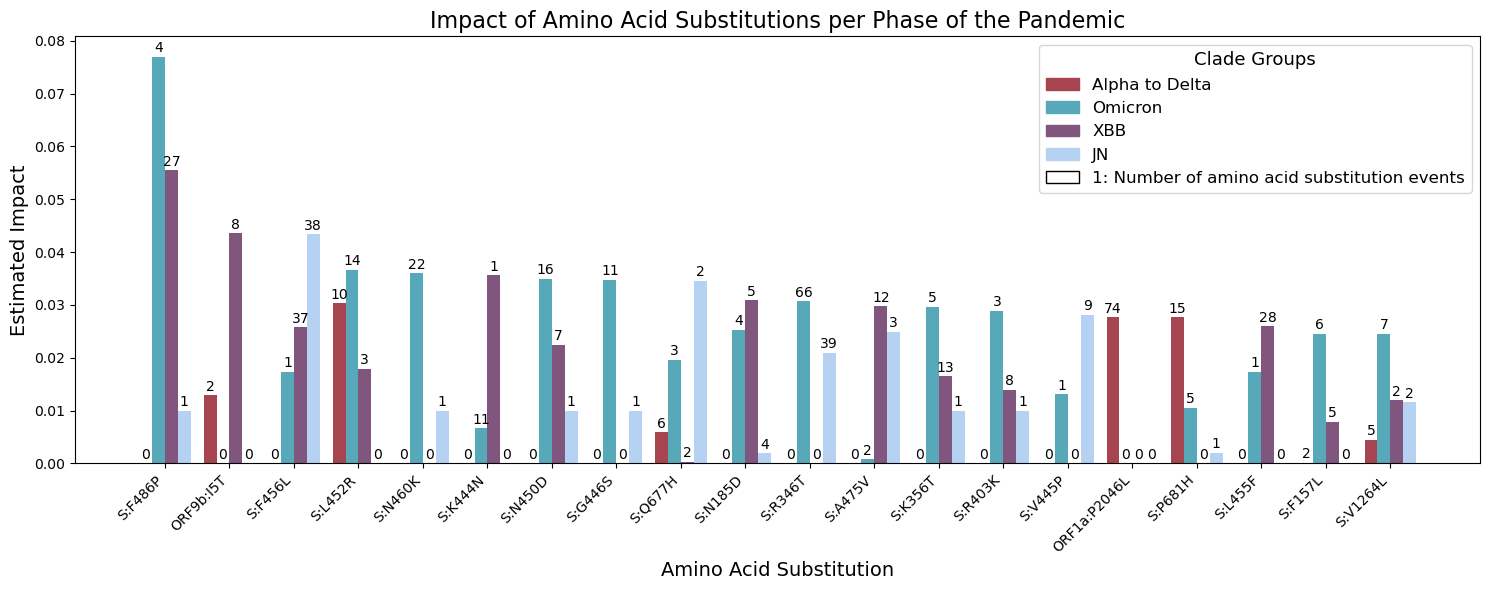

In [97]:
plot_aa_impact_time(aa_impact_time_df, labels, top_n=20, abundancy_threshold=10)
